In [2]:
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from sklearn.ensemble import RandomForestRegressor

### Dagshub/Mlflow initialization ###

In [3]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='sbolk23', repo_name='House-Prices-Kaggle-Competition', mlflow=True)


Accessing as sbolk23

Initialized MLflow to track repo "sbolk23/House-Prices-Kaggle-Competition"

Repository sbolk23/House-Prices-Kaggle-Competition initialized!

In [4]:
PATH = 'data'
TARGET = 'SalePrice'

In [5]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

### Split Train/Test Data ###

In [6]:
df = pd.read_csv(PATH + '/train.csv')

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

train_df, test_df = train_test_split(
    df, test_size=.2, shuffle=True, random_state=1337
)

print(f'train_df shape {train_df.shape}')
print(f'test_df shape {test_df.shape}')

train_df shape (1168, 81)
test_df shape (292, 81)


### Data Cleaning ###

### Remove Outliers ###

In [8]:
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]

train_df = train_df.drop(outliers.index)

X_train = train_df.drop(columns=['SalePrice'])
y_train = train_df['SalePrice']

X_test = test_df.drop(columns=['SalePrice'])
y_test = test_df['SalePrice']

print(f'X_train shape {X_train.shape}')
print(f'X_test shape {X_test.shape}')

X_train shape (1166, 80)
X_test shape (292, 80)


### Categorical Imputing ###

In [9]:
# we first impute all missing values in categorical and numeric features.

# These categorical columns may have 'NaN' values in them which means missing.
# data_description.txt did not mention 'Nan' was intended.

cat_impute_cols = [
    'MSZoning',
    'Street',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'Foundation',
    'ExterQual',
    'ExterCond',
    'Heating',
    'HeatingQC',
    'CentralAir',
    'Electrical',
    'KitchenQual',
    'Functional',
    'PavedDrive',
    'SaleType',
    'SaleCondition',
]

### Numeric Imputing ###

In [10]:
# We impute all numeric columns because data_description.txt did not mention any numeric feature with intended 'NaN' value.

# num_impute_cols = [
#     'LotFrontage',
#     'GarageYrBlt',
#     'MasVnrArea',
# ]

num_impute_cols = list(X_train.select_dtypes(exclude='object').columns)
num_impute_cols.extend(['TotalSF', 'HouseAge'])
num_impute_cols.remove('Id')
num_impute_cols.remove('MSSubClass')

### Categorical One-Hot-Encoded Columns ###

In [11]:
# Here we list features to be one-hot-encoded including 'NaN's because 'NaN' here does not mean missing.
# 'MasVnrType' was interesting column here.

cat_ohe_cols = [
    'MSZoning',
    'Street',
    'Alley',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'GarageType',
    'PavedDrive',
    'MiscFeature',
    'SaleType',
    'SaleCondition',
]

cat_ohe_missing_cols = [
    'MSZoning',
    'Street',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'PavedDrive',
    'SaleType',
    'SaleCondition'
]

cat_ohe_absent_cols = [
    'Alley',
    'MasVnrType',
    'GarageType',
    'MiscFeature'
]

### Ordinal Columns ###

In [12]:
# Some categorical columns can may be ordered, replace them with numbers.

cat_ord_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
]

cat_ord_missing_cols = [
    'ExterQual',
    'ExterCond',
    'HeatingQC',
    'KitchenQual',
    'Functional',
]

cat_ord_absent_cols = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
]

exter_qual_order        = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
exter_cond_order        = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_qual_order         = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_cond_order         = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_exposure_order     = ['NA', 'No', 'Mn', 'Av', 'Gd']
bsmt_fin_type_1_order   = ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
bsmt_fin_type_2_order   = ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
heating_qc_order        = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
kitchen_qual_order      = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
functional_order        = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
fireplace_qu_order      = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
garage_finish_order     = ['NA', 'Unf', 'RFn', 'Fin']
garage_qual_order       = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
garage_cond_order       = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
pool_qc_order           = ['NA', 'Fa', 'TA', 'Gd', 'Ex']
fence_order             = ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

cat_ord_missing_categories = [
    exter_qual_order,
    exter_cond_order,
    heating_qc_order,
    kitchen_qual_order,
    functional_order,
]

cat_ord_absent_categories = [
    bsmt_qual_order,
    bsmt_cond_order,
    bsmt_exposure_order,
    bsmt_fin_type_1_order,
    bsmt_fin_type_2_order,
    fireplace_qu_order,
    garage_finish_order,
    garage_qual_order,
    garage_cond_order,
    pool_qc_order,
    fence_order,
]

### Numeric One-Hot-Encoded Columns ###

In [13]:
# This feature has numeric type which is misleading.

num_ohe_cols = [
    'MSSubClass',
]

### Categorical Target-Encoded Columns ###

In [14]:
# This features have too many categorical values.

cat_te_cols = [
    'Neighborhood',
]

### Irrelevant Columns ###

In [15]:
# This col is not informative.

irrelevant_cols = [
    'Id'
]

### Data Cleanup Pipeline ###

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer

# scaling every column after preprocessing decreased accuracy.
# scaling only numeric columns is sufficient.

num_impute_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='median')),
    ('scale',   StandardScaler()),
])

num_ohe_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

cat_ord_missing_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=cat_ord_missing_categories)),
])

cat_ord_absent_pipeline = Pipeline([
    ('nan_impute',  SimpleImputer(strategy='constant', missing_values=np.nan, fill_value='NA')),
    ('ordinal',     OrdinalEncoder(categories=cat_ord_absent_categories)),
])

cat_ohe_missing_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

cat_ohe_absent_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='constant', missing_values=np.nan, fill_value='Missing')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

cat_te_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='most_frequent')),
    ('te',      TargetEncoder(cv=5, smooth="auto", target_type="continuous", random_state=1337)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_impute',       num_impute_pipeline,       num_impute_cols),
        ('num_ohe',          num_ohe_pipeline,          num_ohe_cols),
        ('cat_ord_absent',   cat_ord_absent_pipeline,   cat_ord_absent_cols),
        ('cat_ord_missing',  cat_ord_missing_pipeline,  cat_ord_missing_cols),
        ('cat_ohe_absent',   cat_ohe_absent_pipeline,   cat_ohe_absent_cols),
        ('cat_ohe_missing',  cat_ohe_missing_pipeline,  cat_ohe_missing_cols),
        # ('cat_te',           cat_te_pipeline,           cat_te_cols),
        ('drop',            'drop',                     irrelevant_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_impute', ...), ('num_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

### Correlation Filter ###

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=.9):
        self.threshold = threshold
        self.features_to_select_ = None
        self.features_to_drop_ = None

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_ser = pd.Series(y).reset_index(drop=True)
        X_df['SalePrice'] = y_ser

        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                correlated_cols = upper.index[upper[col] > self.threshold].tolist()

                for correlated_col in correlated_cols:
                    if correlated_col in self.features_to_drop_:
                        continue

                    if corr[col]['SalePrice'] > corr[correlated_col]['SalePrice']:
                        self.features_to_drop_.add(correlated_col)
                    else:
                        self.features_to_drop_.add(col)
                        break

        self.features_to_select_ = [
            col for col in X.columns if col not in self.features_to_drop_
        ]

        # print(f'Correlation filter selected {str(self.features_to_select_)}')
        # print(f'Correlation filter dropped {str(self.features_to_drop_)}')

        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.features_to_select_]


### Feature Engineering ###

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class TotalSFAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF'] + 1
        return X

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin

class HouseAgeAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['HouseAge'] = X['YrSold'] - X['YearBuilt']
        return X

### Feature Selection ###

In [20]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
selector = SelectKBest(score_func=f_regression, k=30)

### Custom Scorer ###

In [21]:
from sklearn.metrics import make_scorer, root_mean_squared_log_error

def safe_rmsle(y_true, y_pred):
    y_pred_pos = np.maximum(y_pred, 0)
    return root_mean_squared_log_error(y_true, y_pred_pos)

safe_rmsle_scorer = make_scorer(safe_rmsle, greater_is_better=False)

### Full Pipeline (Linear Regression) ###

In [24]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor

pipeline = Pipeline([
    ('total_sf', TotalSFAdder()),
    ('house_age', HouseAgeAdder()),
    ('preprocessor', preprocessor),
    ('corr_filter', CorrelationFilter()),
    ('selector', SelectKBest()),
    ('model', LinearRegression()),
])

final_model = TransformedTargetRegressor(
    regressor=pipeline,
)

param_grid = [
    {
        'regressor__preprocessor__num_impute__impute__strategy': ['mean'],
        'regressor__corr_filter__threshold': [.85, .9, .95],
        'regressor__selector__k': [50, 100, 110, 120, 130, 140, 150, 'all'],
        'regressor__selector__score_func': [f_regression, ],
        'func': [np.log1p],
        'inverse_func': [np.expm1],
    },
]

### MLFlow Logging (Linear Regression) ###

In [25]:
from sklearn.model_selection import KFold
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=1337)

grid_search_cv = GridSearchCV(
    final_model,
    param_grid,
    cv=kf,
    scoring={
        'neg_root_mean_squared_log_error': safe_rmsle_scorer,
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2',
    },
    refit='neg_root_mean_squared_log_error',
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

grid_search_cv.fit(X_train, y_train)
cv_results_df = pd.DataFrame(grid_search_cv.cv_results_)

mlflow.set_experiment('linear_regression_prep_v3')

for i, row in cv_results_df.iterrows():
    row_dict = row.to_dict()

    params              = row_dict['params']
    corr_threshold      = row_dict['param_regressor__corr_filter__threshold']
    k_features          = row_dict['param_regressor__selector__k']
    selector_score_fn   = row_dict['param_regressor__selector__score_func'].__name__
    has_log             = 'logY' if row_dict['param_func'] is not None else 'rawY'
    num_imp             = row_dict['param_regressor__preprocessor__num_impute__impute__strategy']

    run_name = f'LR__prep_v3__{has_log}__num_imp_{num_imp}__ord_imp__ohe__no_outliers__corr_threshold_{corr_threshold}__k_features_{k_features}__feature_selector_score_fn_{selector_score_fn}'

    with mlflow.start_run(run_name=run_name):
        print(f'Logging parameters ({run_name})')
        for key, value in row_dict.items():
            if 'param_' in key:
                mlflow.log_param(key.replace('param_', ''), value)


        mlflow.log_param('outlier_min_threshold_grlivarea', 4000)
        mlflow.log_param('outlier_max_threshold_price', 300000)
        mlflow.log_param('outlier_ids', str(list(outliers['Id'].index)))

        print(f'Logging preprocessing parameters ({run_name})')
        mlflow.log_param('num_impute_cols',         str(num_impute_cols))
        mlflow.log_param('num_ohe_cols',            str(num_ohe_cols))
        mlflow.log_param('cat_ord_absent_cols',     str(cat_ord_absent_cols))
        mlflow.log_param('cat_ord_missing_cols',    str(cat_ord_missing_cols))
        mlflow.log_param('cat_ohe_absent_cols',     str(cat_ohe_absent_cols))
        mlflow.log_param('cat_ohe_missing_cols',    str(cat_ohe_missing_cols))
        mlflow.log_param('irrelevant_cols',         str(irrelevant_cols))
        mlflow.log_param('new_cols',                str(['TotalSF (=TotalBsmtSF+1stFlrSF+2ndFlrSF)', 'HouseAge (=YrSold-YearBuilt)']))

        print(f'Logging train and validation metrics ({run_name})')
        for key, value in row_dict.items():
            if 'rank' in key:
                continue

            if 'neg_root_mean_squared_log_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_log_error', 'rmsle').replace('test', 'validation'), abs(value))

            if 'neg_root_mean_squared_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_error', 'rmse').replace('test', 'validation'), abs(value))

            if 'neg_mean_absolute_error' in key:
                mlflow.log_metric(
                    key.replace('neg_mean_absolute_error', 'mae').replace('test', 'validation'), abs(value))

            if 'r2' in key:
                mlflow.log_metric(key.replace('test', 'validation'), (value))


        # Logging time metrics
        mlflow.log_metric('mean_fit_time',      row_dict['mean_fit_time'])
        mlflow.log_metric('std_fit_time',       row_dict['std_fit_time'])
        mlflow.log_metric('mean_score_time',    row_dict['mean_score_time'])
        mlflow.log_metric('std_score_time',     row_dict['std_score_time'])

        model = clone(final_model)
        model.set_params(**params)

        print(f'Logging final model ({run_name})')
        model.fit(X_train, y_train)

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name='model',
        )

        mlflow.set_tag('model_type', 'LinearRegression')
        mlflow.set_tag('model_id', model_info.model_id)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

### Full Pipeline (Ridge) ###

In [528]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('total_sf', TotalSFAdder()),
    ('house_age', HouseAgeAdder()),
    ('preprocessor', preprocessor),
    ('corr_filter', CorrelationFilter()),
    ('selector', SelectKBest()),
    ('model', Ridge()),
])


final_model = TransformedTargetRegressor(
    regressor=pipeline,
)

param_grid = [
    {
        'regressor__preprocessor__num_impute__impute__strategy': ['mean',],
        'regressor__model__alpha': [10, 15, 25,],
        'regressor__corr_filter__threshold': [.85, .9, .95,],
        'regressor__selector__k': [50, 150, 'all'],
        'regressor__selector__score_func': [f_regression,],
        'func': [np.log1p],
        'inverse_func': [np.expm1],
    },

    #   'regressor__model__alpha': np.linspace(1, 50, 300),
]

### MLFlow Logging (Ridge) ###

In [529]:
from sklearn.model_selection import KFold
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=1337)

grid_search_cv = GridSearchCV(
    final_model,
    param_grid,
    cv=kf,
    scoring={
        'neg_root_mean_squared_log_error': safe_rmsle_scorer,
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2',
    },
    refit='neg_root_mean_squared_log_error',
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

grid_search_cv.fit(X_train, y_train)
cv_results_df = pd.DataFrame(grid_search_cv.cv_results_)

mlflow.set_experiment('linear_regression_prep_v3')

for i, row in cv_results_df.iterrows():
    row_dict = row.to_dict()

    params              = row_dict['params']
    corr_threshold      = row_dict['param_regressor__corr_filter__threshold']
    k_features          = row_dict['param_regressor__selector__k']
    selector_score_fn   = row_dict['param_regressor__selector__score_func'].__name__
    has_log             = 'logY' if row_dict['param_func'] is not None else 'rawY'
    num_imp             = row_dict['param_regressor__preprocessor__num_impute__impute__strategy']

    run_name = f'RIDGE__prep_v3__{has_log}__num_imp_{num_imp}__ord_imp__ohe__no_outliers__corr_threshold_{corr_threshold}__k_features_{k_features}__feature_selector_score_fn_{selector_score_fn}'

    with mlflow.start_run(run_name=run_name):
        print(f'Logging parameters ({run_name})')
        for key, value in row_dict.items():
            if 'param_' in key:
                mlflow.log_param(key.replace('param_', ''), value)


        mlflow.log_param('outlier_min_threshold_grlivarea', 4000)
        mlflow.log_param('outlier_max_threshold_price', 300000)
        mlflow.log_param('outlier_ids', str(list(outliers['Id'].index)))

        print(f'Logging preprocessing parameters ({run_name})')
        mlflow.log_param('num_impute_cols',         str(num_impute_cols))
        mlflow.log_param('num_ohe_cols',            str(num_ohe_cols))
        mlflow.log_param('cat_ord_absent_cols',     str(cat_ord_absent_cols))
        mlflow.log_param('cat_ord_missing_cols',    str(cat_ord_missing_cols))
        mlflow.log_param('cat_ohe_absent_cols',     str(cat_ohe_absent_cols))
        mlflow.log_param('cat_ohe_missing_cols',    str(cat_ohe_missing_cols))
        mlflow.log_param('irrelevant_cols',         str(irrelevant_cols))
        mlflow.log_param('new_cols',                str(['TotalSF (=TotalBsmtSF+1stFlrSF+2ndFlrSF)', 'HouseAge (=YrSold-YearBuilt)']))

        print(f'Logging train and validation metrics ({run_name})')
        for key, value in row_dict.items():
            if 'rank' in key:
                continue

            if 'neg_root_mean_squared_log_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_log_error', 'rmsle').replace('test', 'validation'), abs(value))

            if 'neg_root_mean_squared_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_error', 'rmse').replace('test', 'validation'), abs(value))

            if 'neg_mean_absolute_error' in key:
                mlflow.log_metric(
                    key.replace('neg_mean_absolute_error', 'mae').replace('test', 'validation'), abs(value))

            if 'r2' in key:
                mlflow.log_metric(key.replace('test', 'validation'), (value))


        # Logging time metrics
        mlflow.log_metric('mean_fit_time',      row_dict['mean_fit_time'])
        mlflow.log_metric('std_fit_time',       row_dict['std_fit_time'])
        mlflow.log_metric('mean_score_time',    row_dict['mean_score_time'])
        mlflow.log_metric('std_score_time',     row_dict['std_score_time'])

        model = clone(final_model)
        model.set_params(**params)

        print(f'Logging final model ({run_name})')
        model.fit(X_train, y_train)

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name='model',
        )

        mlflow.set_tag('model_type', 'LinearRegression')
        mlflow.set_tag('model_id', model_info.model_id)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)


2026/04/12 15:57:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/c4a8b3ec3332429a9f92b9390da19ba0
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_fe

2026/04/12 15:59:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/8f2d2082ecb94c16a6da01b86b528b2f
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_f

2026/04/12 16:02:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/cb07a83e42694244a3116f9976490b5b
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_feat

2026/04/12 16:05:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/ede7e816e09d4a789cbb2d17c0b63f01
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_fe

2026/04/12 16:07:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/088c592cf9c8433287362208e4fdd8f4
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_f

2026/04/12 16:10:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/9d5e1108b4254752b53ea793f1c4cfa6
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_feat

2026/04/12 16:12:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/9591c867b68a4945ab7d7e68b9d0eca7
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_fe

2026/04/12 16:15:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/193224bcde7a4f2e9952cf0a92755b86
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_f

2026/04/12 16:18:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/e0aa4d88e7ff47e5b51b9f2e5757505f
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features

2026/04/12 16:20:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/45ad00bb5ded45cc943bf4678d1e9891
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_feature

2026/04/12 16:23:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/907a357257c04dd785b6e4a8f136f837
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_featur

2026/04/12 16:25:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/9ee9ab2f60a442ca8f65785bab154921
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_

2026/04/12 16:28:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/74e0b60ad1ad4e499a506c0098513df2
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_feature

2026/04/12 16:30:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/0b91eaa9033e48baa9192c2cfa10cebe
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_featur

2026/04/12 16:33:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/85f0470caec944c499417807c07b934f
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_

2026/04/12 16:36:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/522eb5250de140bb969c417635180717
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_feature

2026/04/12 16:38:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/cb79957628f347d988a206e288e58770
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_featur

2026/04/12 16:41:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/c1a23ed7559942938ea472e8c7b4ee60
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_featu

2026/04/12 16:43:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/02dc9506771b4e8a9e7d57ba412828c0
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_fe

2026/04/12 16:46:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/b2e2937c62234eb7ae73bb295bec3c22
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_f

2026/04/12 16:49:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/6c26ec1634e64b80b9b0b8155e65291a
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_feat

2026/04/12 16:51:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/76b47e5962b848d4a92b90384f088dc7
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_fe

2026/04/12 16:54:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/957d1d60edb24daea8debb59db195a92
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_f

2026/04/12 16:56:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/3b027cc67c4e4267960bdf7d60adfa0e
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_feat

2026/04/12 17:01:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/d5118db34df244888b058ddfd3f2b6db
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_fe

2026/04/12 17:07:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_150__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/df85bc77c09740469a9caccc89326d24
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_f

2026/04/12 17:12:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RIDGE__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/d03444853d724a288b0efd8f74254437
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4


### Full Pipeline (Lasso) ###

In [530]:
from sklearn.linear_model import Lasso
from sklearn.compose import TransformedTargetRegressor

final_pipeline = Pipeline([
    ('total_sf', TotalSFAdder()),
    ('house_age', HouseAgeAdder()),
    ('preprocessor', preprocessor),
    ('corr_filter', CorrelationFilter()),
    ('selector', SelectKBest()),
    ('model', Lasso(max_iter=100000))
])

final_model = TransformedTargetRegressor(
    regressor=final_pipeline,
)

param_grid = [
    {
        'regressor__preprocessor__num_impute__impute__strategy': ['mean',],
        'regressor__model__alpha': [.0005, .0006, .0007],
        'regressor__corr_filter__threshold': [.85, .9, .95],
        'regressor__selector__k': [50, 100, 'all'],
        'regressor__selector__score_func': [f_regression,],
        'func': [np.log1p],
        'inverse_func': [np.expm1],
    },

    # 'regressor__corr_filter__threshold': np.linspace(.85, .95, 10),
    # 'regressor__model__alpha': np.linspace(.0005, .0007, 20),
    # 'regressor__model__alpha': np.logspace(-4, 1, 300),
]


### MLFlow Logging (Lasso) ###

In [531]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=1337)

grid_search_cv = GridSearchCV(
    final_model,
    param_grid,
    cv=kf,
    scoring={
        'neg_root_mean_squared_log_error': safe_rmsle_scorer,
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2',
    },
    refit='neg_root_mean_squared_log_error',
    return_train_score=True,
    verbose=True,
    n_jobs=6,
)

grid_search_cv.fit(X_train, y_train)
cv_results_df = pd.DataFrame(grid_search_cv.cv_results_)

mlflow.set_experiment('linear_regression_prep_v3')

for i, row in cv_results_df.iterrows():
    row_dict = row.to_dict()

    params              = row_dict['params']
    corr_threshold      = row_dict['param_regressor__corr_filter__threshold']
    k_features          = row_dict['param_regressor__selector__k']
    selector_score_fn   = row_dict['param_regressor__selector__score_func'].__name__
    has_log             = 'logY' if row_dict['param_func'] is not None else 'rawY'
    num_imp             = row_dict['param_regressor__preprocessor__num_impute__impute__strategy']

    run_name = f'LASSO__prep_v3__{has_log}__num_imp_{num_imp}__ord_imp__ohe__no_outliers__corr_threshold_{corr_threshold}__k_features_{k_features}__feature_selector_score_fn_{selector_score_fn}'

    with mlflow.start_run(run_name=run_name):
        print(f'Logging parameters ({run_name})')
        for key, value in row_dict.items():
            if 'param_' in key:
                mlflow.log_param(key.replace('param_', ''), value)


        mlflow.log_param('outlier_min_threshold_grlivarea', 4000)
        mlflow.log_param('outlier_max_threshold_price', 300000)
        mlflow.log_param('outlier_ids', str(list(outliers['Id'].index)))

        print(f'Logging preprocessing parameters ({run_name})')
        mlflow.log_param('num_impute_cols',         str(num_impute_cols))
        mlflow.log_param('num_ohe_cols',            str(num_ohe_cols))
        mlflow.log_param('cat_ord_absent_cols',     str(cat_ord_absent_cols))
        mlflow.log_param('cat_ord_missing_cols',    str(cat_ord_missing_cols))
        mlflow.log_param('cat_ohe_absent_cols',     str(cat_ohe_absent_cols))
        mlflow.log_param('cat_ohe_missing_cols',    str(cat_ohe_missing_cols))
        mlflow.log_param('irrelevant_cols',         str(irrelevant_cols))
        mlflow.log_param('new_cols',                str(['TotalSF (=TotalBsmtSF+1stFlrSF+2ndFlrSF)', 'HouseAge (=YrSold-YearBuilt)']))

        print(f'Logging train and validation metrics ({run_name})')
        for key, value in row_dict.items():
            if 'rank' in key:
                continue

            if 'neg_root_mean_squared_log_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_log_error', 'rmsle').replace('test', 'validation'), abs(value))

            if 'neg_root_mean_squared_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_error', 'rmse').replace('test', 'validation'), abs(value))

            if 'neg_mean_absolute_error' in key:
                mlflow.log_metric(
                    key.replace('neg_mean_absolute_error', 'mae').replace('test', 'validation'), abs(value))

            if 'r2' in key:
                mlflow.log_metric(key.replace('test', 'validation'), (value))


        # Logging time metrics
        mlflow.log_metric('mean_fit_time',      row_dict['mean_fit_time'])
        mlflow.log_metric('std_fit_time',       row_dict['std_fit_time'])
        mlflow.log_metric('mean_score_time',    row_dict['mean_score_time'])
        mlflow.log_metric('std_score_time',     row_dict['std_score_time'])

        model = clone(final_model)
        model.set_params(**params)

        print(f'Logging final model ({run_name})')
        model.fit(X_train, y_train)

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name='model',
        )

        mlflow.set_tag('model_type', 'LinearRegression')
        mlflow.set_tag('model_id', model_info.model_id)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)


2026/04/12 17:25:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/108689545c6442b3987c44aba0b5484c
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_fe

2026/04/12 17:27:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/5f148ebbaad442f6903110d1a6cf13ef
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_f

2026/04/12 17:30:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/7f2955d56b7a43c29f276da5c4af136f
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_feat

2026/04/12 17:32:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/226895cfef1e4948ac37257ba1169092
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_fe

2026/04/12 17:35:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/55c1f61575284d38b3a898f0444651f7
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_f

2026/04/12 17:38:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/1b29cf27440d42c8957abb5d210cb18c
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_feat

2026/04/12 17:40:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/32f0d575865a49a9bdff678fb79bee46
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_fe

2026/04/12 17:43:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/30161a79cdcf476893730fd8e5de2ee0
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_f

2026/04/12 17:45:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.85__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/d99ae7cdec144ccc802cca46808c9511
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features

2026/04/12 17:48:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/2596cabec0ed43ce85d9b0b53623a81a
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_feature

2026/04/12 17:51:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/83ebeccc0e0a4d2bb41819d34e3faa25
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_featur

2026/04/12 17:53:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/bc97ce5a87c14fce8cbf64cf07fa9847
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_

2026/04/12 17:59:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/ed9e316d488b4b44bef47eae81f30eaa
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_feature

2026/04/12 18:04:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/87901c914f594d88b4d6e98f6f1e4cf0
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_featur

2026/04/12 18:09:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/a272d4a6c0fd4e589ae34864f4ecf391
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_

2026/04/12 18:13:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/63491af575b4497b8835b26845c468c1
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_feature

2026/04/12 18:16:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/a12ea7ff4e6c4b3c92272d5f8b12fd56
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_featur

2026/04/12 18:18:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.9__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/d4f3332eda684510a4830c89c70728b9
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_featu

2026/04/12 18:21:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/81814a509c8d4cb491ed6633749c0ad3
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_fe

2026/04/12 18:24:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/69c8558fda67425888f3aa7f02c5b809
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_f

2026/04/12 18:26:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/38b932684a8c46efbbb76e9d934c8a2c
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_feat

2026/04/12 18:29:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/4b8abbc3798b433287b4f6a04be39cfa
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_fe

2026/04/12 18:31:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/0fdb126f84674b8eb3906a932df63490
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_f

2026/04/12 18:34:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/f700c63f8f9d482ebf3980d8ae2aa6ec
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_feat

2026/04/12 18:37:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_50__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/a72f62dcc3ba47498564c638ea6fbee0
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_fe

2026/04/12 18:39:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_100__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/ddeb4081783b47328dd5589a1564be1b
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4
Logging parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging preprocessing parameters (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging train and validation metrics (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression)
Logging final model (LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_f

2026/04/12 18:42:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LASSO__prep_v3__logY__num_imp_mean__ord_imp__ohe__no_outliers__corr_threshold_0.95__k_features_all__feature_selector_score_fn_f_regression at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4/runs/9676c4fe9c1b45ab9b935e0f7a24577e
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/4


### Final Pipeline (ElasticNet) ###

In [508]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.compose import TransformedTargetRegressor

final_pipeline = Pipeline([
    ('total_sf', TotalSFAdder()),
    ('house_age', HouseAgeAdder()),
    ('preprocessor', preprocessor),
    ('corr_filter', CorrelationFilter()),
    ('selector', SelectKBest()),
    ('model', ElasticNet(max_iter=10000)),
])

final_model = TransformedTargetRegressor(
    regressor=final_pipeline,
)

param_grid = {
    'regressor__preprocessor__num_impute__impute__strategy': ['mean'],
    'regressor__model__alpha': [.0005, .0006, .00065, .001,],
    'regressor__model__l1_ratio': [.1, .5, .9, .95, .99, .995],
    'regressor__corr_filter__threshold': [.85, .9, .95],
    'regressor__selector__k': [50, 100, 'all'],
    'regressor__selector__score_func': [f_regression,],
    'func': [np.log1p],
    'inverse_func': [np.expm1],

    # 'regressor__model__alpha': np.logspace(-4, 1, 30),
    # 'regressor__model__l1_ratio': np.linspace(.05, .95, 30),
}

### MLFlow Logging (Elastic Net) ###

In [ ]:
from sklearn.model_selection import KFold
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=1337)

grid_search_cv = GridSearchCV(
    final_model,
    param_grid,
    cv=kf,
    scoring={
        'neg_root_mean_squared_log_error': safe_rmsle_scorer,
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2',
    },
    refit='neg_root_mean_squared_log_error',
    return_train_score=True,
    n_jobs=-1
)

grid_search_cv.fit(X_train, y_train)
cv_results_df = pd.DataFrame(grid_search_cv.cv_results_)

mlflow.set_experiment('linear_regression')

for i, row in cv_results_df.iterrows():
    row_dict = row.to_dict()

    params = row_dict['params']
    alpha = row_dict['param_regressor__model__alpha']
    l1_ratio = row_dict['param_regressor__model__l1_ratio']
    num_imp = row_dict['param_regressor__preprocessor__num_impute__impute__strategy']
    has_log = "logY" if row_dict['param_func'] is not None else "rawY"

    run_name = f'ELASTIC_NET__alpha_{alpha}__l1_ratio_{l1_ratio}__prep_v2__{has_log}__num_imp_{num_imp}__ord_imp__ohe__no_outliers'

    with mlflow.start_run(run_name=run_name):
        print(f'Logging parameters ({run_name})')
        for key, value in row_dict.items():
            if 'param_' in key:
                mlflow.log_param(key.replace('param_', ''), value)

        mlflow.log_param('outlier_min_threshold_grlivarea', 4000)
        mlflow.log_param('outlier_max_threshold_price', 300000)
        mlflow.log_param('outlier_ids', str(list(outliers['Id'].index)))


        print(f'Logging preprocessing parameters ({run_name})')
        mlflow.log_param('num_impute_cols',         str(num_impute_cols))
        mlflow.log_param('num_ohe_cols',            str(num_ohe_cols))
        mlflow.log_param('cat_ord_absent_cols',     str(cat_ord_absent_cols))
        mlflow.log_param('cat_ord_missing_cols',    str(cat_ord_missing_cols))
        mlflow.log_param('cat_ohe_absent_cols',     str(cat_ohe_absent_cols))
        mlflow.log_param('cat_ohe_missing_cols',    str(cat_ohe_missing_cols))
        mlflow.log_param('irrelevant_cols',         str(irrelevant_cols))

        print(f'Logging train and validation metrics ({run_name})')
        for key, value in row_dict.items():
            if 'rank' in key:
                continue

            if 'neg_root_mean_squared_log_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_log_error', 'rmsle').replace('test', 'validation'), abs(value))

            if 'neg_root_mean_squared_error' in key:
                mlflow.log_metric(
                    key.replace('neg_root_mean_squared_error', 'rmse').replace('test', 'validation'), abs(value))

            if 'neg_mean_absolute_error' in key:
                mlflow.log_metric(
                    key.replace('neg_mean_absolute_error', 'mae').replace('test', 'validation'), abs(value))

            if 'r2' in key:
                mlflow.log_metric(key.replace('test', 'validation'), (value))


        # Logging time metrics
        mlflow.log_metric('mean_fit_time',      row_dict['mean_fit_time'])
        mlflow.log_metric('std_fit_time',       row_dict['std_fit_time'])
        mlflow.log_metric('mean_score_time',    row_dict['mean_score_time'])
        mlflow.log_metric('std_score_time',     row_dict['std_score_time'])

        model = clone(final_model)
        model.set_params(**params)

        print(f'Logging final model ({run_name})')
        model.fit(X_train, y_train)

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name='model',
        )

        mlflow.set_tag('model_type', 'LinearRegression')
        mlflow.set_tag('model_id', model_info.model_id)


### Decision Tree ###

In [24]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor

final_pipeline = Pipeline([
    ('total_sf', TotalSFAdder()),
    ('house_age', HouseAgeAdder()),
    ('preprocessor', preprocessor),
    ('corr_filter', CorrelationFilter()),
    ('selector', SelectKBest()),
    ('model', DecisionTreeRegressor(random_state=1337))
])

final_model = TransformedTargetRegressor(
    regressor=final_pipeline,
)

param_grid = [
    {
        'regressor__preprocessor__num_impute__impute__strategy': ['mean'],
        'regressor__model__max_depth': [5, 10, 15, 20,],
        'regressor__model__min_samples_leaf': [5, 10, 15,],
        'regressor__model__ccp_alpha': [.00001, .0001, .001, ],
        'regressor__corr_filter__threshold': [.8, .85, .9, .95, ],
        'regressor__selector__k': ['all'],
        'regressor__selector__score_func': [f_regression,],
        'func': [np.log1p],
        'inverse_func': [np.expm1],
    },
]

### MLFlow Logging (Decision Tree) ###

In [27]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=1337)

grid_search_cv = GridSearchCV(
    final_model,
    param_grid,
    cv=kf,
    scoring={
        'neg_root_mean_squared_log_error': safe_rmsle_scorer,
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error',
        'r2': 'r2',
    },
    refit='neg_root_mean_squared_log_error',
    return_train_score=True,
    verbose=True,
    n_jobs=6,
)

grid_search_cv.fit(X_train, y_train)
cv_results_df = pd.DataFrame(grid_search_cv.cv_results_)
t = cv_results_df[['mean_train_neg_root_mean_squared_log_error', 'mean_test_neg_root_mean_squared_log_error']]
t['diff'] = t['mean_test_neg_root_mean_squared_log_error'] - t['mean_train_neg_root_mean_squared_log_error']
t
# mlflow.set_experiment('decision_tree_prep_v3')

# for i, row in cv_results_df.iterrows():
#     row_dict = row.to_dict()
#
#     params              = row_dict['params']
#     max_depth           = row_dict['param_regressor__model__max_depth']
#     min_sample_leaf     = row_dict['param_regressor__model__min_samples_leaf']
#     corr_threshold      = row_dict['param_regressor__corr_filter__threshold']
#     k_features          = row_dict['param_regressor__selector__k']
#     selector_score_fn   = row_dict['param_regressor__selector__score_func'].__name__
#     has_log             = 'logY' if row_dict['param_func'] is not None else 'rawY'
#     num_imp             = row_dict['param_regressor__preprocessor__num_impute__impute__strategy']
#
#     run_name = f'DT__prep_v3__max_depth_{max_depth}__min_sample_leaf_{min_sample_leaf}__{has_log}__num_imp_{num_imp}__ord_imp__ohe__no_outliers__corr_threshold_{corr_threshold}__k_features_{k_features}__feature_selector_score_fn_{selector_score_fn}'
#
#     with mlflow.start_run(run_name=run_name):
#         print(f'Logging parameters ({run_name})')
#         for key, value in row_dict.items():
#             if 'param_' in key:
#                 mlflow.log_param(key.replace('param_', ''), value)
#
#
#         mlflow.log_param('outlier_min_threshold_grlivarea', 4000)
#         mlflow.log_param('outlier_max_threshold_price', 300000)
#         mlflow.log_param('outlier_ids', str(list(outliers['Id'].index)))
#
#         print(f'Logging preprocessing parameters ({run_name})')
#         mlflow.log_param('num_impute_cols',         str(num_impute_cols))
#         mlflow.log_param('num_ohe_cols',            str(num_ohe_cols))
#         mlflow.log_param('cat_ord_absent_cols',     str(cat_ord_absent_cols))
#         mlflow.log_param('cat_ord_missing_cols',    str(cat_ord_missing_cols))
#         mlflow.log_param('cat_ohe_absent_cols',     str(cat_ohe_absent_cols))
#         mlflow.log_param('cat_ohe_missing_cols',    str(cat_ohe_missing_cols))
#         mlflow.log_param('irrelevant_cols',         str(irrelevant_cols))
#         mlflow.log_param('new_cols',                str(['TotalSF (=TotalBsmtSF+1stFlrSF+2ndFlrSF)', 'HouseAge (=YrSold-YearBuilt)']))
#
#         print(f'Logging train and validation metrics ({run_name})')
#         for key, value in row_dict.items():
#             if 'rank' in key:
#                 continue
#
#             if 'neg_root_mean_squared_log_error' in key:
#                 mlflow.log_metric(
#                     key.replace('neg_root_mean_squared_log_error', 'rmsle').replace('test', 'validation'), abs(value))
#
#             if 'neg_root_mean_squared_error' in key:
#                 mlflow.log_metric(
#                     key.replace('neg_root_mean_squared_error', 'rmse').replace('test', 'validation'), abs(value))
#
#             if 'neg_mean_absolute_error' in key:
#                 mlflow.log_metric(
#                     key.replace('neg_mean_absolute_error', 'mae').replace('test', 'validation'), abs(value))
#
#             if 'r2' in key:
#                 mlflow.log_metric(key.replace('test', 'validation'), (value))
#
#
#         # Logging time metrics
#         mlflow.log_metric('mean_fit_time',      row_dict['mean_fit_time'])
#         mlflow.log_metric('std_fit_time',       row_dict['std_fit_time'])
#         mlflow.log_metric('mean_score_time',    row_dict['mean_score_time'])
#         mlflow.log_metric('std_score_time',     row_dict['std_score_time'])
#
#         model = clone(final_model)
#         model.set_params(**params)
#
#         print(f'Logging final model ({run_name})')
#         model.fit(X_train, y_train)
#
#         model_info = mlflow.sklearn.log_model(
#             sk_model=model,
#             name='model',
#         )
#
#         mlflow.set_tag('model_type', 'DecisionTree')
#         mlflow.set_tag('model_id', model_info.model_id)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


/tmp/ipykernel_8868/2949965726.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['diff'] = t['mean_test_neg_root_mean_squared_log_error'] - t['mean_train_neg_root_mean_squared_log_error']


,mean_train_neg_root_mean_squared_log_error,mean_test_neg_root_mean_squared_log_error,diff
0,-0.174081,-0.219538,-0.045457
1,-0.179154,-0.219057,-0.039903
2,-0.185664,-0.223521,-0.037858
3,-0.110824,-0.207427,-0.096603
4,-0.144362,-0.211385,-0.067023
...,...,...,...
139,-0.168126,-0.197004,-0.028878
140,-0.170471,-0.198828,-0.028357
141,-0.166293,-0.195751,-0.029458
142,-0.168126,-0.197004,-0.028878


### Decision Tree (Cost Complexity Pruning) ###

In [28]:
from sklearn.tree import DecisionTreeRegressor

preprocessor_pipeline = Pipeline([
    ('total_sf', TotalSFAdder()),
    ('house_age', HouseAgeAdder()),
    ('preprocessor', preprocessor),
])

preprocessor_pipeline.fit(X_train, y_train)

X_train_t = preprocessor_pipeline.transform(X_train)
y_train_t = np.log1p(y_train)

X_test_t = preprocessor_pipeline.transform(X_test)
y_test_t = np.log1p(y_test)


reg_dt = DecisionTreeRegressor(random_state=1337)
path = reg_dt.cost_complexity_pruning_path(X_train_t, y_train_t)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

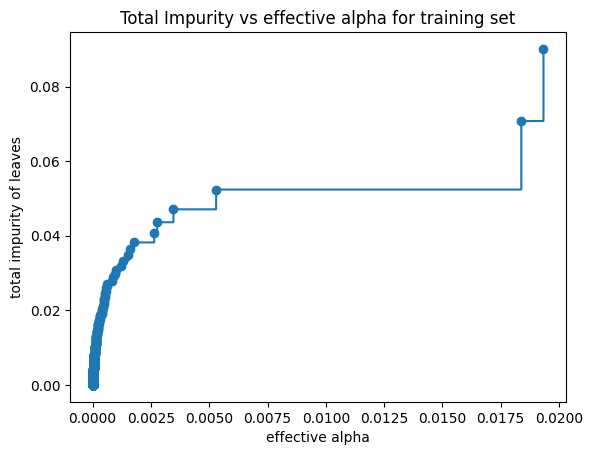

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [ ]:
reg_dts = []
for ccp_alpha in ccp_alphas:
    reg_dt = DecisionTreeRegressor(random_state=1337, ccp_alpha=ccp_alpha)
    reg_dt.fit(X_train_t, y_train_t)
    reg_dts.append(reg_dt)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        reg_dts[-1].tree_.node_count, ccp_alphas[-1]
    )
)

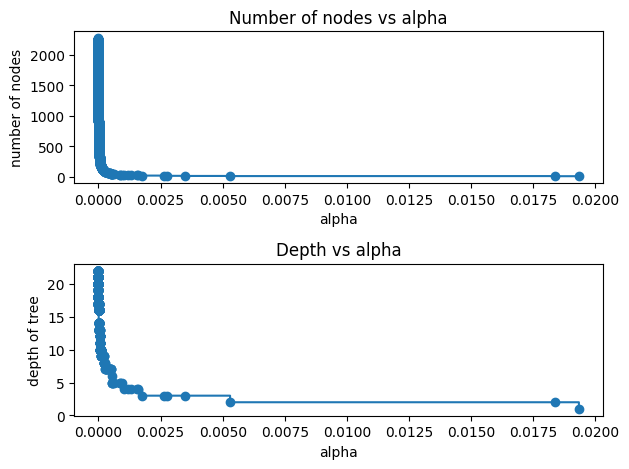

In [30]:
reg_dts = reg_dts[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [reg_dt.tree_.node_count for reg_dt in reg_dts]
depth = [reg_dt.tree_.max_depth for reg_dt in reg_dts]

fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [46]:
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=1337)

alpha_loop_values = []

for ccp_alpha in ccp_alphas:
    reg_dt = DecisionTreeRegressor(ccp_alpha=ccp_alpha, random_state=1337)

    cv_scores = cross_val_score(
        reg_dt, X_train_t, y_train_t,
        cv=kf,
        scoring='neg_root_mean_squared_error',
    )

    alpha_loop_values.append([ccp_alpha, np.mean(-cv_scores), np.std(-cv_scores)])

alpha_results = pd.DataFrame(alpha_loop_values, columns=['alpha', 'mean', 'std'])

In [48]:
alpha_results.sort_values(by='mean').head(n=10)

,alpha,mean,std
1064,0.000201,0.190275,0.012048
1065,0.000206,0.190482,0.012525
1052,0.000148,0.190756,0.010581
1053,0.000148,0.190756,0.010581
1055,0.000152,0.190780,0.010638
1054,0.000152,0.190780,0.010638
1056,0.000155,0.190859,0.010654
1066,0.000209,0.190970,0.012036
1060,0.000169,0.191098,0.011349
1063,0.000186,0.191162,0.012635


In [37]:
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

train_scores = [
    root_mean_squared_error(y_train_t, reg_dt.predict(X_train_t)) 
    for reg_dt in reg_dts
]

test_scores = [
    root_mean_squared_error(y_test_t, reg_dt.predict(X_test_t)) 
    for reg_dt in reg_dts
]

# for reg_dt in reg_dts:
#     if root_mean_squared_error(y_test_t, reg_dt.predict(X_test_t)) == 0.16450111376434173:
#         print(reg_dt.ccp_alpha)
#         break

# print(np.min(test_scores))

fig, ax = plt.subplots(figsize=(20, 15))
ax.set_xlabel("alpha")
ax.set_ylabel("rmsle")
ax.set_title("rmsle vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

KeyboardInterrupt: 

### Final Test scores ###

In [61]:
from sklearn.metrics import root_mean_squared_error

runs_df = mlflow.search_runs(experiment_names=["linear_regression"])

for run_id in runs_df["run_id"]:
    models = mlflow.search_logged_models(
        filter_string=f"source_run_id = '{run_id}'",
        output_format="list",
    )

    model_id = models[0].model_id
    model = mlflow.sklearn.load_model(f"models:/{model_id}")
    y_pred = model.predict(X_test)

    test_rmse = root_mean_squared_error(y_test, y_pred)

    with mlflow.start_run(run_id=run_id):
        mlflow.log_metric('test_rmse', test_rmse)


🏃 View run LR__prep_v1__num_imp_median__ord_imp__ohe at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/1/runs/f7155e7f2be3435e919d5aab2e1b0bf5
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/1


🏃 View run LR__prep_v1__num_imp_mean__ord_imp__ohe at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/1/runs/339189ffc2fd4096a73dc763dce0fffb
🧪 View experiment at: https://dagshub.com/sbolk23/House-Prices-Kaggle-Competition.mlflow/#/experiments/1
